In [164]:
# simple notebook for images generation for the thesis

# all images in pdf format

In [165]:
import os

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from matplotlib.patches import Ellipse
# import matplotlib; matplotlib.use('Agg')
from matplotlib.patches import Rectangle
from pathlib import Path

from skimage.draw import ellipse

In [166]:
fits_path = "../../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"

catalogue_path = "../../data/curated/bubbles_catalogue.txt"

output_file = "../../outputs/testing/figures"

os.makedirs(output_file, exist_ok=True)

PC_PER_PX = 5.2544
# ACCENT = '#FF0000'


In [167]:
hdul = fits.open(fits_path)
hdul.info()

data = hdul[1].data
header = hdul[1].header

print(data.shape)
print(np.nanmin(data), np.nanmax(data))


Filename: ../../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     265   ()      
  1  SCI           1 ImageHDU        75   (2380, 1177)   float32   
  2  ERR           1 ImageHDU        10   (2380, 1177)   float32   
  3  CON           1 ImageHDU        10   (2380, 1177, 1)   int32   
  4  WHT           1 ImageHDU         9   (2380, 1177)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2380, 1177)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2380, 1177)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2380, 1177)   float32   
  8  HDRTAB        1 BinTableHDU    502   12R x 246C   [23A, 5A, 3A, 48A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 70A, 11A, 2A, 47A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 6A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 7A, 7A, 5A, D, D, D, D, D, D, 27A, D, D, 4A, 8A, 5A, 4A, 3A, 4A, K, 5A, 9A, D, D, D, D

In [168]:
def add_generic_scalebar(ax, kpc=1.0, x=500, y=60, color="white"):
    length_px = (kpc * 1000.0) / PC_PER_PX
    ax.plot([x, x + length_px], [y, y], color=color, lw=2.5,
            solid_capstyle="butt")
    ax.text(x + length_px / 2, y + 25, f"{kpc:g} kpc", color=color,
            ha="center", fontsize=10)

def save_generic(fig, stem):
    for ext in ("pdf", "png"):
        path = os.path.join(output_file, f"{stem}.{ext}")
        fig.savefig(path, dpi=300 if ext == "png" else 200,
                    bbox_inches="tight")
        print("Saved image at ", path)


Saved image at  ../../outputs/testing/figures/ngc628_testing.pdf
Saved image at  ../../outputs/testing/figures/ngc628_testing.png


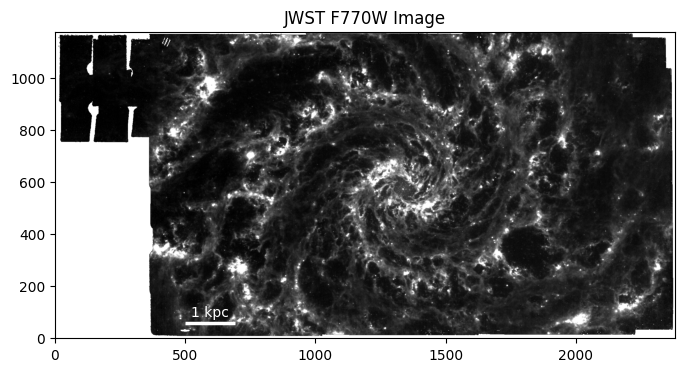

In [169]:
# plt.figure(figsize=(8, 8))
fig, ax = plt.subplots(figsize=(8, 8))

plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
add_generic_scalebar(ax)

plt.title("JWST F770W Image")
# plt.show()

save_generic(fig, "ngc628_testing")
plt.show()



In [170]:
# # saving figure 

# output_image_path = os.path.join(output_file,  "ngc628_testing.png")

# add_generic_scalebar(ax)

# plt.imsave(
#     output_image_path,
#     data, 
#     cmap="gray",
#            vmin=np.nanpercentile(data, 1),
#            vmax=np.nanpercentile(data, 99))

# print("Saved image at ", output_image_path)
# plt.show()

In [171]:
df = pd.read_csv(catalogue_path)

print(df.head())
print(df.columns)

   ID       RA_DMS      DEC_DMS  SEMI_MAJ_PC  SEMI_MIN_PC  AVG_RAD_PC  PA_DEG  \
0   1   24d09m4.2s  15d48m10.3s          219           91         177      70   
1   2   24d09m5.1s  15d48m10.8s          110            0          73      70   
2   3  24d10m11.5s   15d48m8.0s          256          183         232      70   
3   4  24d10m16.5s  15d47m11.4s           35           35          35       0   
4   5  24d10m16.5s   15d47m4.2s           25           25          25       0   

   ARM  DIST_ARM_PC  GAL_RAD_KPC  
0  NaN          NaN         4.99  
1  NaN          NaN         4.98  
2  NaN          NaN         3.26  
3  NaN          NaN         0.65  
4  NaN          NaN         0.45  
Index(['ID', 'RA_DMS', 'DEC_DMS', 'SEMI_MAJ_PC', 'SEMI_MIN_PC', 'AVG_RAD_PC',
       'PA_DEG', 'ARM', 'DIST_ARM_PC', 'GAL_RAD_KPC'],
      dtype='str')


In [172]:
def ra_dec_to_deg(ra_str, dec_str):
    coords = SkyCoord(ra=ra_str, dec=dec_str, frame="icrs")
    return coords.ra.deg, coords.dec.deg

ra_degrees, dec_degrees = ra_dec_to_deg(
        df["RA_DMS"].to_numpy(),
        df["DEC_DMS"].to_numpy()
    )


In [173]:
wcs = WCS(header)
print(wcs) 

x_pix, y_pix = wcs.all_world2pix(ra_degrees, dec_degrees, 0)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 24.171680195437894 15.788156932392056
CRPIX : 1176.2406743555237 589.0158147454987
PC1_1 PC1_2  : 0.3421816464879256 -0.939633822723944
PC2_1 PC2_2  : -0.939633822723944 -0.3421816464879256
CDELT : 3.08127265990853e-05 3.08127265990853e-05
NAXIS : 2380  1177


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


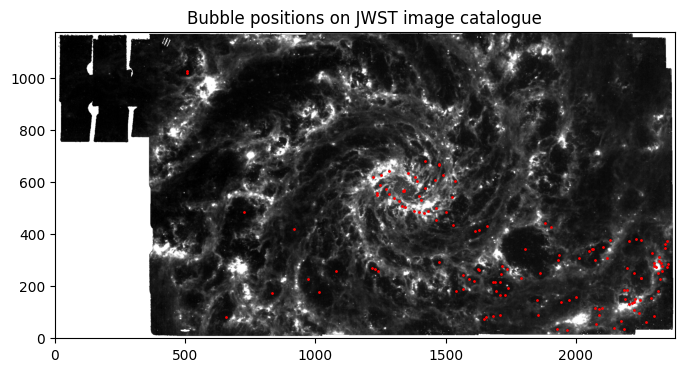

In [174]:
# sanity check  

plt.figure(figsize=(8, 8))

# plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

plt.scatter(x_pix, y_pix, s=1, color='red')
plt.title("Bubble positions on JWST image catalogue")

plt.show()

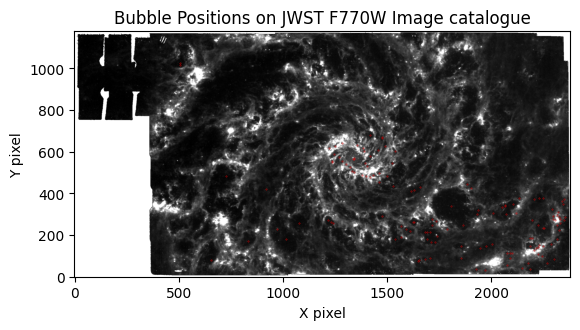

Saved image at  ../../outputs/testing/figures/image_ngc628_bubble_positions_overlay.png


In [175]:
# # saving figure to pdf

plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.scatter(x_pix, y_pix, s=.1, color="red", alpha=0.7)
plt.title("Bubble Positions on JWST F770W Image catalogue")

plt.xlabel("X pixel")
plt.ylabel("Y pixel")

output_center_path = os.path.join(output_file, "image_ngc628_bubble_positions_overlay.png")

plt.savefig(
    output_center_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved image at ", output_center_path)


In [176]:
# mask generation :  parsec to pixel

# Distance to NGC 628 in parsecs
distance_pc = 9.77e6

# Pixel scale from FITS header
pixel_scale_deg = abs(header['CDELT1'])
pixel_scale_arcsec = pixel_scale_deg * 3600

# Physical scale
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc per pixel:", pc_per_pixel)

pc per pixel: 5.254140159227344


In [177]:
mask = np.zeros(data.shape, dtype=np.uint8)     

In [178]:
# semi major and semi minor conversion

import astropy.units as u

semi_major_pix = df['SEMI_MAJ_PC'] / pc_per_pixel
semi_minor_pix = df['SEMI_MIN_PC'] / pc_per_pixel
pa_deg = df['PA_DEG']

# PA_DEG holds DS9's raw fk5 angle, which is measured from the east-west
# axis, not from north. Adding 90 gives a true position angle (E of N).
# Set this to 0 if the catalogue is ever written with true PAs.
DS9_TO_PA_OFFSET = 90.0

# Sky PA -> pixel-frame angle. The mosaic is rotated (~70 deg for this
# F770W image), so the angle has to go through the WCS: step 1" along
# the major axis on the sky and see which way that points in pixels.
centres = SkyCoord(ra=ra_degrees * u.deg, dec=dec_degrees * u.deg)
tips = centres.directional_offset_by(
    (pa_deg.to_numpy() + DS9_TO_PA_OFFSET) * u.deg, 1 * u.arcsec)
x_tip, y_tip = wcs.all_world2pix(tips.ra.deg, tips.dec.deg, 0)

# degrees, counter-clockwise from +x with origin="lower"
angle_pix_deg = np.degrees(np.arctan2(y_tip - y_pix, x_tip - x_pix))

# DS9's default (unrotated) ellipse is PA_DEG=70 and should lie along +x
print("pixel angle for PA_DEG=70:", angle_pix_deg[pa_deg.to_numpy() == 70][:3])

pixel angle for PA_DEG=70: [0.01542908 0.0153611  0.01034316]


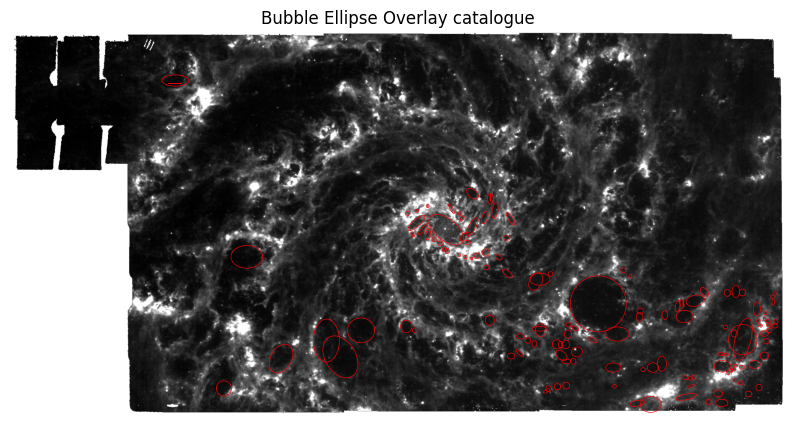

Saved image at  ../../outputs/testing/figures/ngc628_f770w_bubble_positions.png


In [179]:

fig, ax = plt.subplots(figsize=(10, 10))

plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    # matplotlib wants degrees, in the pixel frame
    angle = angle_pix_deg[i]

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    ellipse_patch = Ellipse(
        xy=(x0, y0),
        width=2 * a,
        height=2 * b,
        angle=angle,
        edgecolor="red",
        facecolor="none",
        linewidth=.5,
        alpha=0.9,
    )

    ax.add_patch(ellipse_patch)

ax.set_title("Bubble Ellipse Overlay catalogue")

ax.set_axis_off()

output_overlay_path = os.path.join(output_file, "ngc628_f770w_bubble_positions.png")

plt.savefig(
    output_overlay_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved image at ", output_overlay_path)


In [180]:
mask[:] = 0   # so re-running this cell doesn't accumulate

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_major_pix.iloc[i]
    b = semi_minor_pix.iloc[i]
    # skimage works in (row, col) and rotates the opposite way to an
    # origin="lower" plot, so the angle is negated to match the overlay
    rotation = -np.deg2rad(angle_pix_deg[i])

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) or np.isnan(b):
        continue

    rr, cc = ellipse(
        r=y0,
        c=x0,
        r_radius=b,
        c_radius=a,
        rotation=rotation,
        shape=mask.shape
    )

    mask[rr, cc] = 1

/Users/shailajamahara/nn_env/lib/python3.11/site-packages/skimage/draw/draw.py:51: RuntimeWarning: divide by zero encountered in divide
  distances = ((r * cos_alpha + c * sin_alpha) / r_rad) ** 2 + (


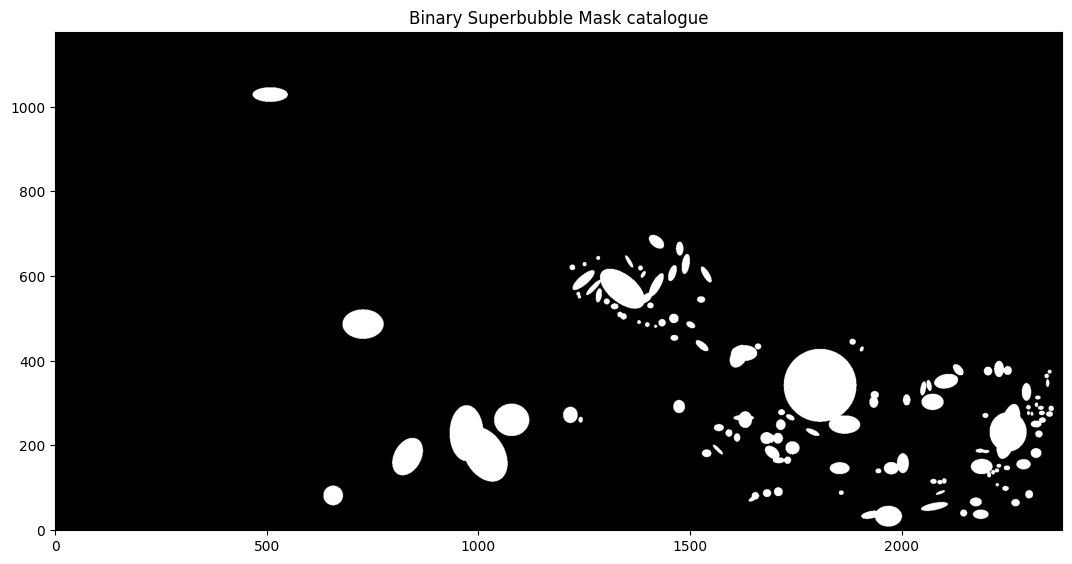

Saved image at  ../../outputs/testing/figures/ngc628Mask.png


In [181]:
plt.figure(figsize=(13, 6.6))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Binary Superbubble Mask catalogue")

overlayabc_path = os.path.join(output_file, "ngc628Mask.png")

plt.savefig(overlayabc_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved image at ", overlayabc_path)


ZScale limits: 9.564 .. 17.522
Saved image at  ../../outputs/testing/figures/ngc628_f770w_raw.pdf
Saved image at  ../../outputs/testing/figures/ngc628_f770w_raw.png


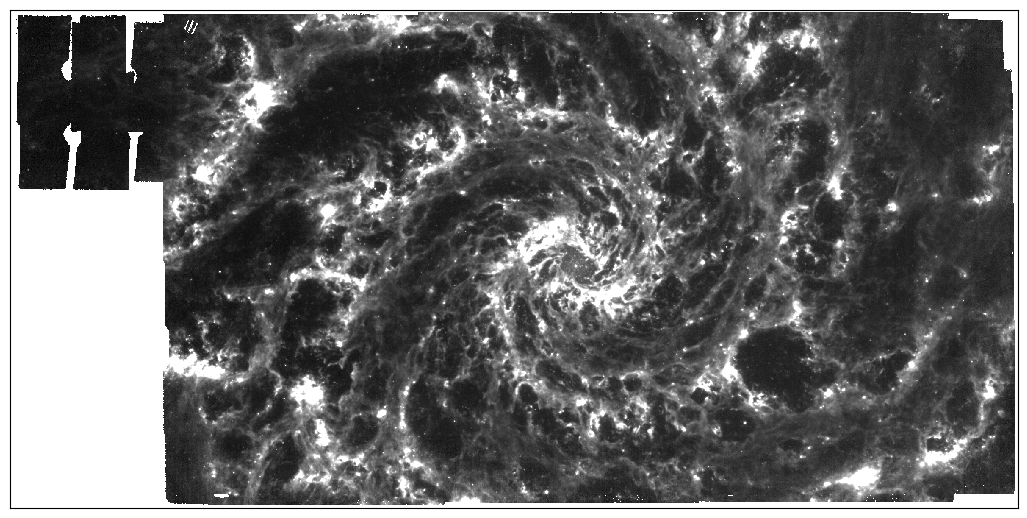

Saved image at  ../../outputs/testing/figures/ngc628MaskOverlay.pdf
Saved image at  ../../outputs/testing/figures/ngc628MaskOverlay.png


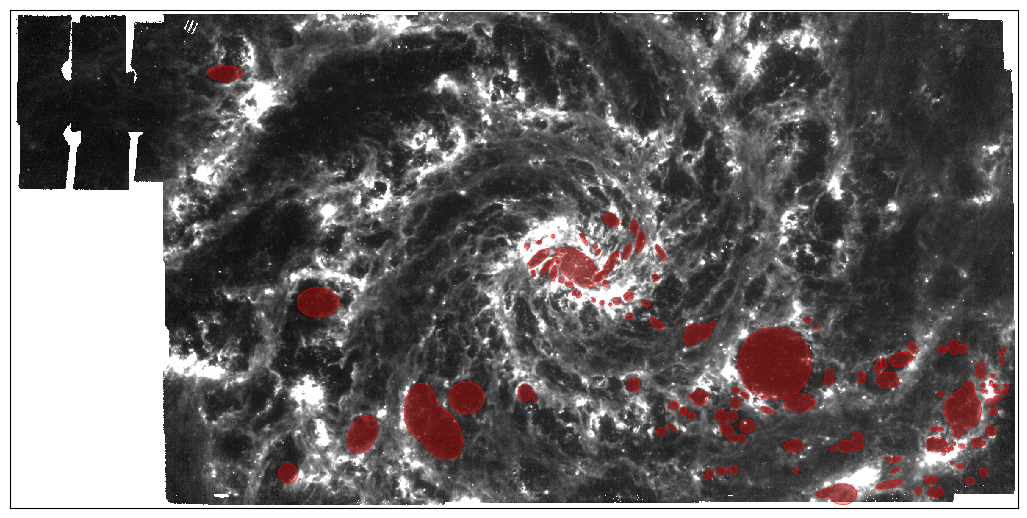

Annotated fraction of the imaged area: 4.2%


In [182]:
# ---------------------------------------------------------------
# Publication figures: raw mosaic and mask overlay, rendered
# identically so the two can be compared directly in the thesis.
#
# Conventions (shared with the patch-tier and cutout figures):
#   - original, non-normalised mosaic
#   - ZScaleInterval limits, computed once and reused by both figures
#   - grayscale image; NaN (outside the detector footprint) drawn in
#     NAN_COLOR. White keeps the irregular mosaic outline visible against
#     the page; black makes the footprint blend into the dark sky and the
#     mosaic then reads as a rectangular crop.
#   - no in-figure title and no pixel axes; captions carry that text
#   - 1 kpc scale bar
# The mask is drawn as a translucent fill with a solid outline, so the
# emission underneath stays visible and alignment can be judged.
# ---------------------------------------------------------------

from astropy.visualization import ZScaleInterval
from matplotlib.colors import ListedColormap

ACCENT = "#FF0000"
NAN_COLOR = "white"   # "white" shows the mosaic footprint; "black" hides it
z1, z2 = ZScaleInterval(contrast=0.25).get_limits(data)
print(f"ZScale limits: {z1:.3f} .. {z2:.3f}")
    
def draw_mosaic(ax, image, overlay=None, outline_lw=0.35):
    """Grayscale mosaic with NaN in black; optional translucent overlay."""
    im = ax.imshow(np.ma.masked_invalid(image), origin="lower", cmap="gray",
                   vmin=z1, vmax=z2, interpolation="nearest")
    im.cmap.set_bad(NAN_COLOR)

    if overlay is not None:
        binary = overlay.astype(bool)
        # mask the zeros, otherwise imshow paints the background too
        ax.imshow(np.ma.masked_where(~binary, binary), origin="lower",
                  cmap=ListedColormap([ACCENT]), alpha=0.32,
                  interpolation="nearest")
        ax.contour(binary.astype(float), levels=[0.5],
                   colors=[ACCENT], linewidths=outline_lw)

    ax.set_xticks([])
    ax.set_yticks([])
    return ax


def add_scalebar(ax, kpc=1.0, x=80, y=60, color="black"):
    length_px = (kpc * 1000.0) / pc_per_pixel
    ax.plot([x, x + length_px], [y, y], color=color, lw=2.5,
            solid_capstyle="butt")
    ax.text(x + length_px / 2, y + 25, f"{kpc:g} kpc", color=color,
            ha="center", fontsize=10)


def save(fig, stem):
    for ext in ("pdf", "png"):
        path = os.path.join(output_file, f"{stem}.{ext}")
        fig.savefig(path, dpi=300 if ext == "pdf" else 200,
                    bbox_inches="tight")
        print("Saved image at ", path)


# --- raw mosaic, no annotations --------------------------------
fig, ax = plt.subplots(figsize=(13, 6.6))
draw_mosaic(ax, data)
# add_scalebar(ax)
save(fig, "ngc628_f770w_raw")
plt.show()

# --- same rendering, with the union mask overlaid --------------
fig, ax = plt.subplots(figsize=(13, 6.6))
draw_mosaic(ax, data, overlay=mask)
# add_scalebar(ax)
save(fig, "ngc628MaskOverlay")
plt.show()

print(f"Annotated fraction of the imaged area: {100 * mask.astype(bool).mean():.1f}%")
